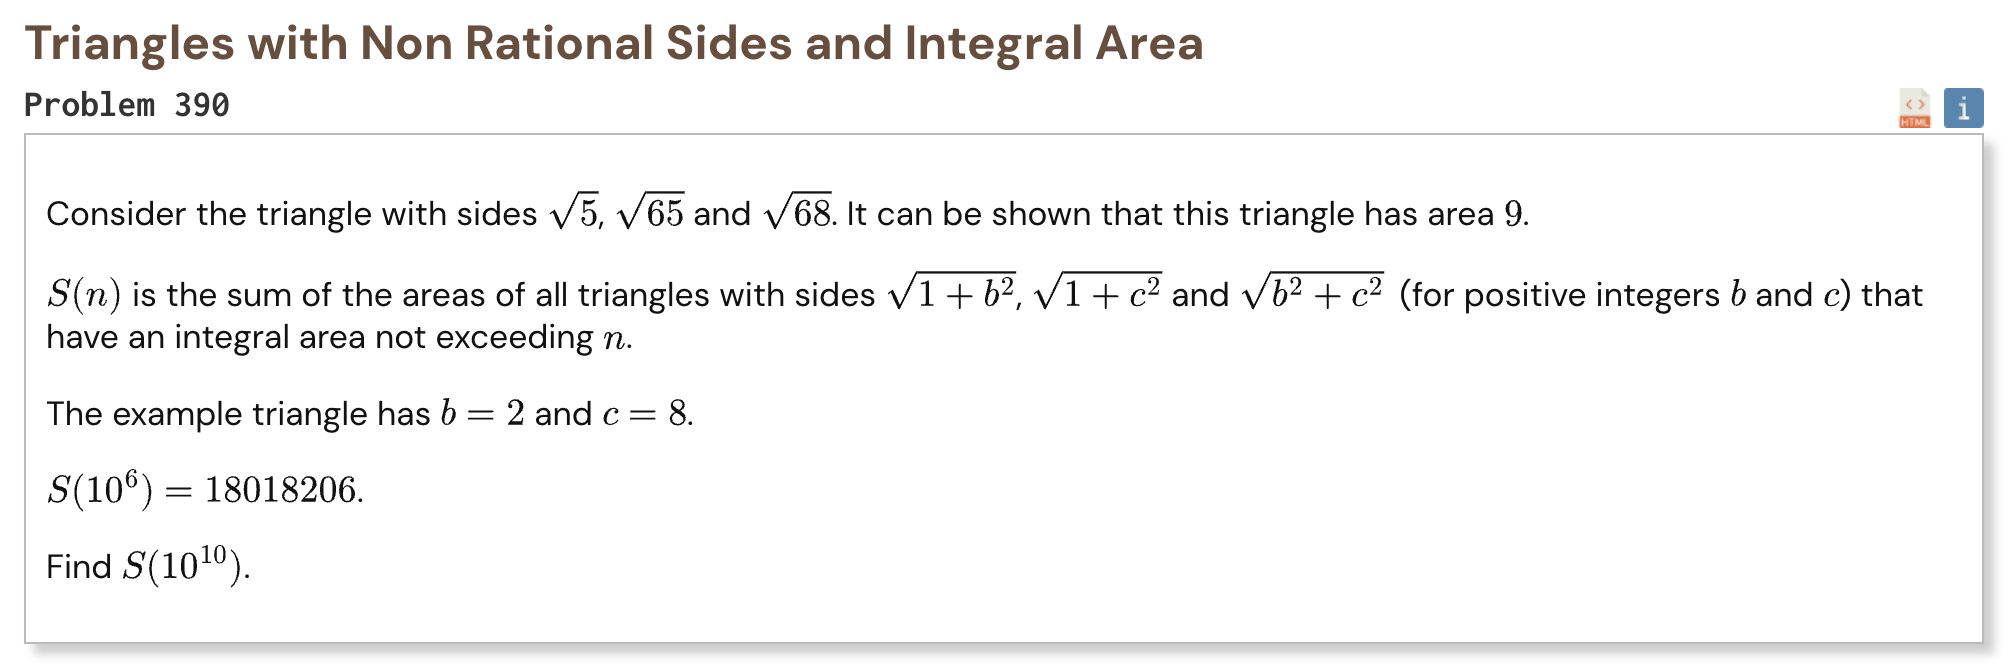

## Initial approach

* use Heron’s formula to simplify the area to half the square root of b squared times c squared plus b squared plus c squared
* an integral area is only possible when both b and c are even
* write b as 2p and c as 2q to get a generalized Pell equation
* for each fixed p start from the simple solution q equals zero and area equals p
* apply a recurrence to generate the next valid positive q and integral area
* use symmetry between p and q to create the other solution branches
* stop a branch as soon as its area becomes larger than the limit
* add every generated area and verify the method with the given one million example

In [1]:
def find_p_limit(limit):
    low = 0
    high = 1

    while 8 * high ** 3 + high <= limit:
        high *= 2

    while low + 1 < high:
        middle = (low + high) // 2

        if 8 * middle ** 3 + middle <= limit:
            low = middle
        else:
            high = middle

    return low


def solve(limit):
    p_limit = find_p_limit(limit)
    stack = [(p, 0, p) for p in range(1, p_limit + 1)]
    total = 0

    while stack:
        p, q, area = stack.pop()

        multiplier = 8 * p * p + 1
        q_new = multiplier * q + 4 * p * area
        area_new = (
            4 * p * (4 * p * p + 1) * q
            + multiplier * area
        )

        if area_new > limit:
            continue

        total += area_new

        stack.append((p, q_new, area_new))
        stack.append((q_new, p, area_new))
        stack.append((q_new, -p, area_new))

    return total

In [2]:
%%time
assert solve(10 ** 6) == 18018206
result = solve(10 ** 10)
print("Result:", result)

Result: 2919133642971
CPU times: user 3.13 ms, sys: 136 μs, total: 3.26 ms
Wall time: 3.25 ms
